# YOLO11s 객체 탐지 모델 v2 → v3 차이 및 성능 분석 보고서

**대상**: 던전앤파이터 캐릭터/닉네임 탐지 모델 (`character`, `user_id` 2-class)
**비교 버전**: v2 (정적 데이터 학습) vs v3 (정적 + 동영상 프레임 학습)
**작성일**: 2026-06-14 | **환경**: RTX 5090, Ultralytics YOLO11s, PyTorch cu128

---
본 보고서는 v2 → v3 전환 시 **학습 데이터에 동영상 프레임(자동 라벨)을 대량 추가**한 변경이
정적 이미지 평가와 동영상 추적 평가에 미친 영향을 분석한다. 두 모델은 **구조·하이퍼파라미터가
동일(YOLO11s, imgsz 1280, batch 8)하며 학습 데이터만 다르다.** 따라서 모든 지표 차이는
**데이터 변화에 기인**한다.

## 1. Executive Summary (요약)

v3는 v2 대비 **실제 동영상 환경에서의 탐지·추적 성능이 향상**된 반면, **정적 이미지에서의
박스 정밀도(mAP50-95)와 재현율(Recall)은 소폭 하락**했다. 이는 단일한 "개선"이 아니라
**명확한 트레이드오프**이며, 그 원인은 v3에 추가된 721장의 동영상 프레임 데이터 성질에 있다.

| 구분 | 핵심 변화 | 방향 |
|---|---|---|
| 정적 mAP50 (느슨한 IoU) | 0.923 → **0.931** | ▲ 개선 |
| 정적 mAP50-95 (엄격한 IoU) | 0.591 → **0.573** | ▼ 하락 |
| 정적 Precision | 0.869 → **0.908** | ▲ 개선 |
| 정적 Recall | 0.858 → **0.834** | ▼ 하락 |
| 동영상 내 캐릭터 추적률 | 0.840 → **0.858** | ▲ 개선 |
| 동영상 캐릭터 탐지율 | 0.885 → **0.888** | ▲ 개선 |

**한 줄 요약**: v3는 **정적 이미지의 박스 정밀도·재현율을 일부 희생**하는 대신,
**실사용 동영상 도메인에서의 탐지·추적 안정성을 확보**했다. 이 트레이드오프의 근본 원인은
동영상 프레임의 **자동 라벨링(pseudo-label) 노이즈**와 **모션 블러/이펙트 가림**이다.

In [1]:
# 공통 설정 및 지표 데이터
from pathlib import Path
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
from IPython.display import Image, display
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

ROOT = Path(r"C:\Users\park\Desktop\MINI_DATA_PROJECT")
ASSETS = ROOT / "report_v2_v3_assets"

# 정적 이미지 평가 (val: 사람 라벨 stills 90장, 동일 평가셋)
static = {
    'mAP50':     (0.923, 0.931),
    'mAP50-95':  (0.591, 0.573),
    'Precision': (0.869, 0.908),
    'Recall':    (0.858, 0.834),
}
# 동영상 추적 평가 (holdout 07-25, 3,841프레임, 동일 후처리)
dynamic = {
    '내 캐릭터\n추적률': (0.840, 0.858),
    '캐릭터\n탐지율':    (0.885, 0.888),
    'user_id\n탐지율':   (0.909, 0.903),
}
COL = {'v2': '#888888', 'v3': '#3a7afe'}
print("v2 train: 2,817장 (실사 817 + 합성 2,000 + 영상 0)")
print("v3 train: 3,538장 (실사 817 + 합성 2,000 + 영상 721)")

v2 train: 2,817장 (실사 817 + 합성 2,000 + 영상 0)
v3 train: 3,538장 (실사 817 + 합성 2,000 + 영상 721)


## 2. 데이터셋 및 학습 환경의 변화

### 2.1 양적 변화 (Quantitative)

학습 데이터는 **실사 + 합성 2,817장에서, 동영상 프레임 721장을 추가한 3,538장으로 +25.6% 증가**했다.
검증셋(val)과 모델 구조·하이퍼파라미터는 **완전히 동일하게 고정**하여 데이터 효과만 분리했다.

| 항목 | v2 | v3 | 비고 |
|---|---|---|---|
| train 총 이미지 | 2,817 | **3,538** | +721 (+25.6%) |
| ├ 실사 스크린샷 | 817 | 817 | 동일 (labelme 수작업) |
| ├ 합성(스프라이트) | 2,000 | 2,000 | 동일 |
| └ **영상 프레임** | **0** | **721** | **신규 (pseudo-label)** |
| val | 90 | 90 | 동일 (사람 라벨 stills) |
| 학습 epoch | 51 (조기종료) | 80 (완주) | — |
| 공통 설정 | \multicolumn{2}{c}{yolo11s · imgsz 1280 · batch 8 · split seed 42 · 합성·영상은 train만} | |

> 영상 프레임 721장은 동영상 5개 중 **4개에서 0.5fps로 추출**했으며, 나머지 1개(07-25)는
> **평가 전용 holdout**으로 학습에서 제외하여 동영상 평가의 공정성을 확보했다.

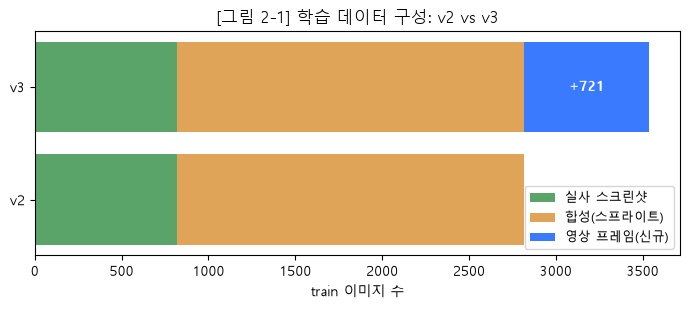

In [2]:
# [그림 2-1] train 데이터 구성 변화
fig, ax = plt.subplots(figsize=(7, 3.2))
labels = ['v2', 'v3']
real = [817, 817]; synth = [2000, 2000]; video = [0, 721]
ax.barh(labels, real, color='#5aa469', label='실사 스크린샷')
ax.barh(labels, synth, left=real, color='#e0a458', label='합성(스프라이트)')
ax.barh(labels, video, left=[a+b for a,b in zip(real,synth)], color='#3a7afe', label='영상 프레임(신규)')
for i,(r,s,v) in enumerate(zip(real,synth,video)):
    if v: ax.text(r+s+v/2, i, f'+{v}', va='center', ha='center', color='white', fontweight='bold')
ax.set_xlabel('train 이미지 수'); ax.set_title('[그림 2-1] 학습 데이터 구성: v2 vs v3')
ax.legend(loc='lower right', fontsize=9); plt.tight_layout(); plt.show()

### 2.2 질적 변화 (Qualitative) — 가장 중요한 분석 포인트

추가된 721장은 단순한 "데이터 증가"가 아니라 **성질이 근본적으로 다른 데이터**다. 이 질적 차이가
이후 모든 지표 변화의 원인이 된다.

| 항목 | v2 데이터 | v3 추가분 (영상 프레임) |
|---|---|---|
| 종류 | 정적 스크린샷 + 알파 스프라이트 합성 | 동영상 캡처 프레임 |
| 해상도 | 단일 (실사 1772×900) | 다양 (1016 / 1064 / 1600 / 1976) |
| 화질 특성 | **깨끗한 정지 화면** | **동영상 압축 아티팩트 · 모션 블러** |
| 장면 | 일반 스크린샷 | 스킬 이펙트 가림 · 다인 파티/레이드 다수 |
| 라벨 출처 | 실사=labelme 수작업(GT), 합성=정확 좌표 | **v2 모델 pseudo-label** (자동, conf 0.5, 사람 검수 X) |
| 라벨 신뢰도 | 높음 (Ground Truth) | **노이즈 존재** (특히 가려진 파티원 = False Negative 잔존) |

**두 가지 노이즈 원천이 동시에 유입되었다:**
1. **모션 블러/이펙트** → 객체 경계가 흐려져 **박스 좌표의 정답 자체가 부정확**해진다.
2. **Pseudo-label의 False Negative** → v2가 놓친 가려진 파티원은 라벨이 없어, 모델 입장에서는
   "캐릭터가 있는데 배경으로 학습"하게 된다. 즉 **일부 정답 객체를 '탐지하지 말라'고 가르친 셈**이다.

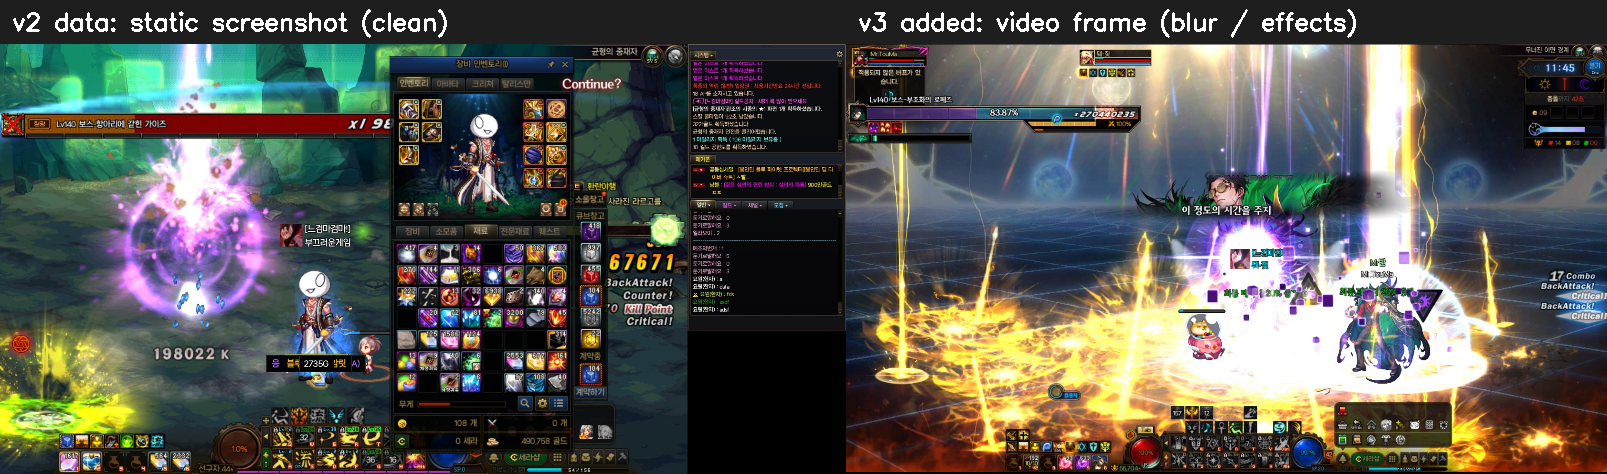

좌: v2 학습 데이터(깨끗한 정지 화면)  |  우: v3 추가 데이터(압축·모션블러·이펙트 가림)


In [3]:
# [그림 2-2] 데이터 성질 비교: 정적 스크린샷(좌) vs 동영상 프레임(우)
display(Image(filename=str(ASSETS / "data_nature.png")))
print("좌: v2 학습 데이터(깨끗한 정지 화면)  |  우: v3 추가 데이터(압축·모션블러·이펙트 가림)")

## 3. 모델 성능 지표 분석

평가는 두 축으로 수행한다: **(A) 정적 이미지 평가**(사람 라벨 val 90장)와
**(B) 동영상 추적 평가**(holdout 07-25, 3,841프레임). 두 평가의 결과가 **상반된 방향**을
가리키며, 이 대비가 v3의 성격을 규정한다.

### 3.1 정적 이미지 평가 (Static) — 박스 정밀도·재현율의 하락

| 지표 | v2 | v3 | Δ | 해석 |
|---|---|---|---|---|
| mAP50 (IoU≥0.5) | 0.923 | **0.931** | ▲ +0.008 | 객체 "발견" 능력은 유지/개선 |
| mAP50-95 (IoU 0.5~0.95) | 0.591 | **0.573** | ▼ −0.018 | **박스 정밀도(tight IoU) 하락** |
| Precision | 0.869 | **0.908** | ▲ +0.039 | 오탐 감소, 더 보수적·확신적 예측 |
| Recall | 0.858 | **0.834** | ▼ −0.024 | **놓치는 객체 증가** |

**(1) mAP50 ▲ 이지만 mAP50-95 ▼ — 박스 정밀도 저하**
mAP50은 IoU 0.5의 느슨한 기준이라 "대략 맞으면" 정답으로 친다. 반면 mAP50-95는 IoU 0.5~0.95의
엄격한 기준으로 **박스가 얼마나 정확히 들어맞는가**를 본다. v3에서 mAP50은 올랐으나 mAP50-95가
떨어진 것은, **객체를 찾기는(발견) 더 잘하지만 박스 경계는 덜 정밀해졌다**는 의미다.
원인은 §2.2의 **모션 블러·이펙트로 흐려진 경계 + 자동 라벨의 좌표 부정확성**이다. 흐릿한 정답으로
학습한 모델은 박스를 느슨하게 그리는 경향을 학습한다.

**(2) Precision ▲ 이지만 Recall ▼ — 가려진 파티원(False Negative) 학습의 직접적 결과**
이 둘은 동전의 양면이다.
- **Recall 하락(0.858→0.834)**: pseudo-label에는 **v2가 놓친 가려진 파티원이 라벨링되지 않은 채**
  포함되었다. 모델은 이 "라벨 없는 진짜 캐릭터"를 **음성(배경)으로 학습**하므로, 비슷한 상황(가림·밀집)에서
  **탐지를 억제**하도록 편향된다 → 놓치는 객체 증가 → Recall 하락.
- **Precision 상승(0.869→0.908)**: 동일한 편향이 모델을 **더 보수적**으로 만든다. 확신이 높을 때만
  탐지하게 되어 오탐(False Positive)이 줄고 Precision은 오른다. 또한 영상 프레임의 인간형 NPC·소환수가
  character로 라벨되지 않아 **하드 네거티브**로 작용한 점도 오탐 억제에 기여했다.

> **요약**: "가려진 파티원 미탐지"라는 라벨 노이즈가 모델을 **"확신할 때만 탐지하는 보수적 탐지기"** 로
> 이동시켰다. 그 결과 Precision↑·오탐↓ 이지만 Recall↓·미탐↑ 이라는 전형적 패턴이 나타났다.

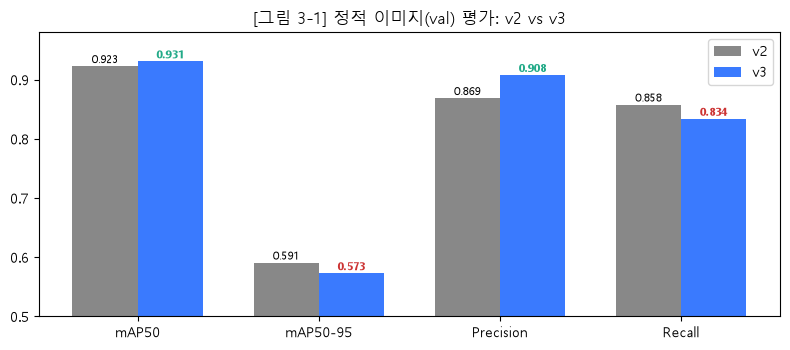

In [4]:
# [그림 3-1] 정적 이미지 평가 지표 비교
fig, ax = plt.subplots(figsize=(8, 3.6))
keys = list(static.keys()); import numpy as np
x = np.arange(len(keys)); w = 0.36
v2 = [static[k][0] for k in keys]; v3 = [static[k][1] for k in keys]
ax.bar(x-w/2, v2, w, label='v2', color=COL['v2'])
ax.bar(x+w/2, v3, w, label='v3', color=COL['v3'])
for i,(a,b) in enumerate(zip(v2,v3)):
    ax.text(i-w/2, a+0.005, f'{a:.3f}', ha='center', fontsize=8)
    ax.text(i+w/2, b+0.005, f'{b:.3f}', ha='center', fontsize=8,
            color=('#2a8' if b>=a else '#c33'), fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(keys); ax.set_ylim(0.5, 0.98)
ax.set_title('[그림 3-1] 정적 이미지(val) 평가: v2 vs v3'); ax.legend()
plt.tight_layout(); plt.show()

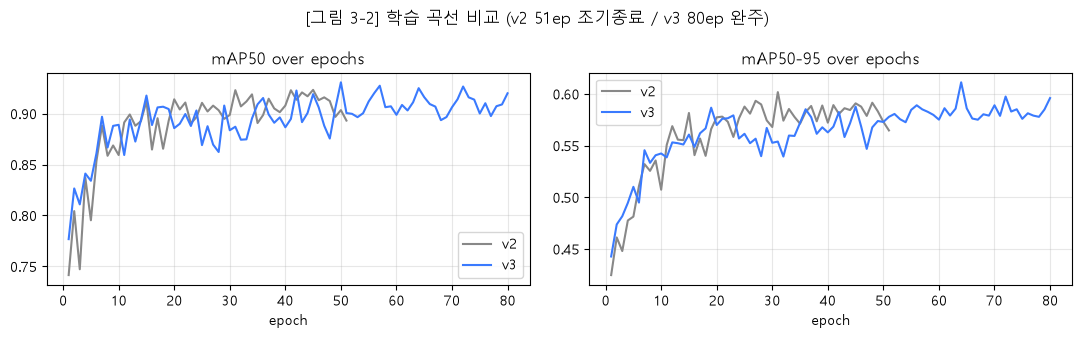

In [5]:
# [그림 3-2] 학습 곡선 (mAP50 / mAP50-95 over epochs)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for run, name, c in [("df_yolo11s_1280_v2","v2",COL['v2']), ("df_yolo11s_1280_v3","v3",COL['v3'])]:
    csv = ROOT / "runs" / run / "results.csv"
    if not csv.exists(): continue
    df = pd.read_csv(csv); df.columns = [c.strip() for c in df.columns]
    ep = df['epoch']
    axes[0].plot(ep, df['metrics/mAP50(B)'], label=name, color=c)
    axes[1].plot(ep, df['metrics/mAP50-95(B)'], label=name, color=c)
axes[0].set_title('mAP50 over epochs'); axes[1].set_title('mAP50-95 over epochs')
for a in axes: a.set_xlabel('epoch'); a.legend(); a.grid(alpha=0.3)
fig.suptitle('[그림 3-2] 학습 곡선 비교 (v2 51ep 조기종료 / v3 80ep 완주)')
plt.tight_layout(); plt.show()

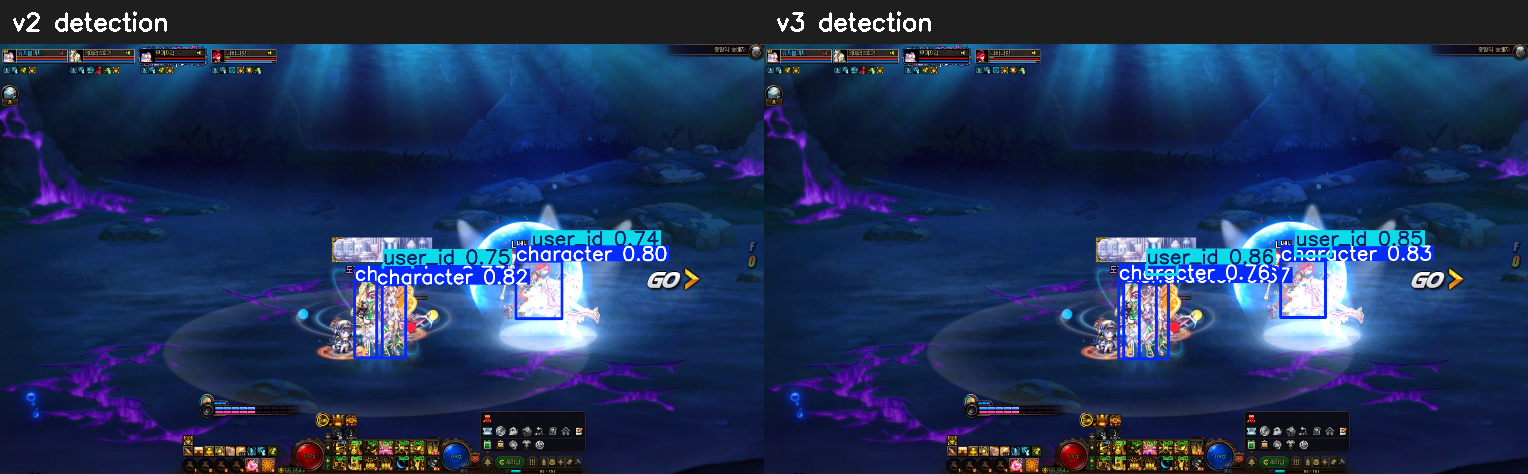

In [6]:
# [그림 3-3] v2 vs v3 탐지 비교 (동일 다인 파티 프레임, 07-25 holdout)
display(Image(filename=str(ASSETS / "det_compare.png")))

### 3.2 동영상 추적 평가 (Dynamic) — 실사용 환경에서의 향상

정적 val은 **v2가 이미 정복한 깨끗한 stills 도메인**이라 v3의 진짜 목적(동영상)을 대변하지 못한다.
실제 목적 환경인 **holdout 동영상(07-25, 3,841프레임)** 에서 측정하면 결과는 정반대로 **v3가 우세**하다.

| 지표 | v2 | v3 | Δ | 해석 |
|---|---|---|---|---|
| 내 캐릭터 추적률 | 0.840 | **0.858** | ▲ +0.018 | 후처리 락온이 더 안정적으로 유지 |
| 캐릭터 탐지율 | 0.885 | **0.888** | ▲ +0.003 | 동영상 도메인 적응 효과 |
| user_id 탐지율 | 0.909 | 0.903 | ▼ −0.006 | 사실상 동등 |
| ID 스위치 | 270 | 276 | ≈ | 탐지가 아닌 **후처리(선정 정책)** 영역 |

**해석**: v3는 학습 중 **압축·블러·이펙트가 섞인 동영상 프레임에 노출**되었기 때문에, 동일한 성질의
holdout 동영상에서 **도메인 갭이 줄어** 탐지·추적이 안정적이다. 정적 val에서 손해 본 박스 정밀도는
**느슨한 추적 목적(객체의 대략 위치 추정)에는 영향이 작고**, 오히려 "찾아내는 능력(mAP50·동영상 탐지율)"의
이득이 추적률 향상으로 이어졌다.

> ID 스위치(270→276)가 개선되지 않은 것은 탐지 모델의 한계가 아니라 **"내 캐릭터 선정 후처리"의
> 진동** 때문이며, 이는 학습이 아닌 **추적 로직(hysteresis 락) 수정**으로 다뤄야 하는 별도 과제다.

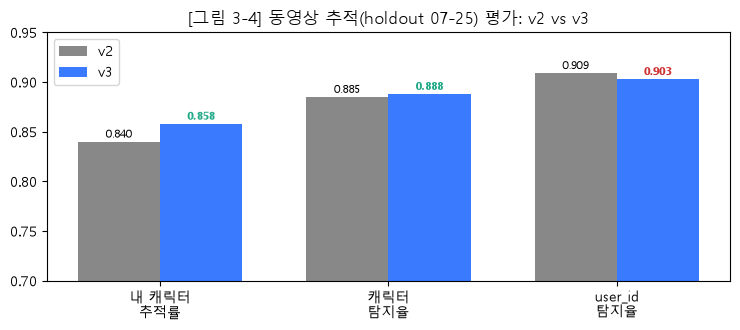

In [7]:
# [그림 3-4] 동영상 추적 평가 지표 비교
fig, ax = plt.subplots(figsize=(7.5, 3.4))
keys = list(dynamic.keys()); x = np.arange(len(keys)); w = 0.36
v2 = [dynamic[k][0] for k in keys]; v3 = [dynamic[k][1] for k in keys]
ax.bar(x-w/2, v2, w, label='v2', color=COL['v2'])
ax.bar(x+w/2, v3, w, label='v3', color=COL['v3'])
for i,(a,b) in enumerate(zip(v2,v3)):
    ax.text(i-w/2, a+0.004, f'{a:.3f}', ha='center', fontsize=8)
    ax.text(i+w/2, b+0.004, f'{b:.3f}', ha='center', fontsize=8,
            color=('#2a8' if b>=a else '#c33'), fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(keys); ax.set_ylim(0.7, 0.95)
ax.set_title('[그림 3-4] 동영상 추적(holdout 07-25) 평가: v2 vs v3'); ax.legend()
plt.tight_layout(); plt.show()

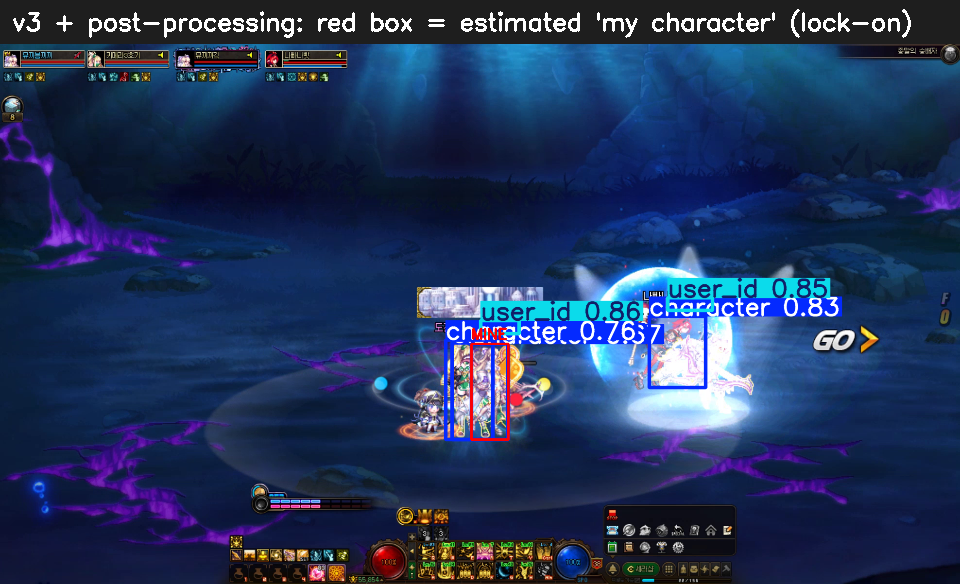

In [8]:
# [그림 3-5] v3 추적 + '내 캐릭터' 락온 예시 (빨간 박스)
display(Image(filename=str(ASSETS / "tracking_example.png")))

## 4. 결론 및 향후 개선 방향

### 4.1 결론 — 트레이드오프의 본질

v3 전환은 **"정적 이미지 정밀도 ↔ 동영상 실사용 성능"의 트레이드오프**다.

- **얻은 것**: 동영상 도메인 적응 → 실제 영상에서 캐릭터 탐지율·내 캐릭터 추적률 상승,
  정적 mAP50·Precision 개선.
- **잃은 것**: 자동 라벨 노이즈(False Negative)와 모션 블러로 인한 **박스 정밀도(mAP50-95)·재현율(Recall) 하락**.

이 트레이드오프는 **데이터 품질 문제이지 모델 용량 문제가 아니다.** 즉 더 큰 모델이나 더 긴 학습이
아니라, **라벨 노이즈를 줄이는 것**이 다음 개선의 핵심 레버다.

### 4.2 향후 개선 방향 (Next Steps)

| 우선순위 | 과제 | 기대 효과 |
|---|---|---|
| 1 | **Pseudo-label 사람 검수** — 가려진 파티원(FN) 보강 + NPC·소환수 오탐(FP) 제거 | **Recall 회복**, 라벨 노이즈 제거로 mAP50-95 개선 |
| 2 | **모션 블러 프레임 정제** — 블러 심한 프레임의 박스 좌표 보정/제외 | **박스 정밀도(mAP50-95) 회복** |
| 3 | **추적 후처리(hysteresis 락) 고도화** — ID 스위치 감소 | 모델 재학습 없이 추적 연속성 개선 |
| 4 | **반복적 self-training** — 검수된 v3로 재-라벨 → 더 깨끗한 v4 데이터 | FN/FP 동시 축소의 선순환 |

**권고**: 현재 v3는 **동영상 실사용 모델로 채택**하되(실환경 성능이 v2보다 우수),
**1순위 과제(pseudo-label 검수)를 통해 라벨 노이즈를 제거한 v4**로 Recall·박스 정밀도를
회복하는 것이 다음 단계의 핵심이다. 검수 인프라(클릭식 O/X 검수 페이지)는 이미 구축되어 있다.

---
*본 보고서의 모든 수치는 동일 평가셋·동일 후처리 기준으로 측정되었으며, 모델 구조·하이퍼파라미터는
v2와 v3가 동일하다. 따라서 관측된 모든 차이는 학습 데이터 변화에 기인한다.*